# Module 5: Diffussion Model

In [1]:
# Clone the repository
!git clone https://github.com/madaan/minimal-text-diffusion.git
%cd minimal-text-diffusion

# Install system dependencies for mpi4py
!apt-get install libopenmpi-dev

# Install Python requirements
!pip install -r requirements.txt
!pip install mpi4py

Cloning into 'minimal-text-diffusion'...
remote: Enumerating objects: 463, done.
remote: Counting objects: 100% (155/155), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 463 (delta 132), reused 110 (delta 110), pack-reused 308 (from 1)
Receiving objects: 100% (463/463), 4.41 MiB | 33.67 MiB/s, done.
Resolving deltas: 100% (264/264), done.
/content/minimal-text-diffusion
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libopenmpi-dev is already the newest version (4.1.2-2ubuntu1).
libopenmpi-dev set to manually installed.
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 19.7 MB/s eta 0:00:0000:010:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 58.9 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build whe

In [ ]:
%%writefile /content/minimal-text-diffusion/setup.py
from setuptools import setup, find_packages

setup(
    name="minimal_text_diffusion",
    version="0.1",
    packages=find_packages(),
    install_requires=[
        "torch",
        "numpy",
        "tqdm",
        "transformers",
    ],
)

Writing /content/minimal-text-diffusion/setup.py


In [3]:
# Install the current directory as a package
!pip install -e .

Obtaining file:///content/minimal-text-diffusion
  Preparing metadata (setup.py) ... done
  Running setup.py develop for minimal_text_diffusion


In [4]:
# Create a word-level tokenizer for the example dataset
!python src/utils/custom_tokenizer.py train-word-level data/simple/simple.txt

[00:00:00] Pre-processing files (0 Mo)    ██████████████████                100%[1, 7, 10, 5, 2]
Encoding(num_tokens=5, attributes=[ids, type_ids, tokens, offsets, attention_mask, special_tokens_mask, overflowing])


In [5]:
from src.utils.custom_tokenizer import create_tokenizer

tokenizer = create_tokenizer(
    return_pretokenized=False,
    path="data/simple"
)

print("Vocab size:", tokenizer.vocab_size)

Vocab size: 165


## Experiment Setup

### 1. Text-to-Text Diffusion: What Are We Training?

In this notebook, we train a **text diffusion model** that generates text by
**iteratively denoising continuous token embeddings** rather than predicting tokens
autoregressively.

High-level idea:

1. Text → token embeddings (continuous vectors)
2. Add Gaussian noise over many diffusion steps
3. Train a Transformer to denoise embeddings conditioned on time
4. Decode the final embeddings back into discrete tokens

This approach follows *Diffusion-LM–style* modeling:
- diffusion happens in **embedding space**
- language structure comes from a **Transformer encoder**
- discreteness is enforced via a **token-level decoding loss**

In the next sections, we will:
- define all training hyperparameters explicitly (instead of using bash scripts)
- construct the model and diffusion process
- run a minimal training loop

In [6]:
import torch
import os
from dataclasses import dataclass

# For reproducibility
SEED = 60637
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cuda


In [ ]:
@dataclass
class DiffusionConfig:
    # ===== Data =====
    dataset: str = "simple"
    train_txt_path: str = "data/simple-train.txt"
    val_txt_path: str = "data/simple-test.txt"
    sequence_len: int = 32
    batch_size: int = 16

    # ===== Diffusion process =====
    diffusion_steps: int = 200
    noise_schedule: str = "sqrt"   # linear | cosine | sqrt
    predict_xstart: bool = True    # model predicts x_0 (clean embedding)

    # ===== Model =====
    config_name: str = "bert-base-uncased"
    in_channel: int = 64           # embedding dimension
    out_channel: int = 64
    num_channels: int = 64         # Transformer hidden channels
    num_heads: int = 2
    dropout: float = 0.1

    # ===== Embeddings =====
    init_pretrained: bool = False
    use_pretrained_embeddings: bool = False
    freeze_embeddings: bool = False

    # ===== Optimization =====
    lr: float = 1e-4
    weight_decay: float = 0.0
    lr_anneal_steps: int = 25000

    # ===== Logging / checkpoints =====
    checkpoint_path: str = "ckpts/simple"


In [8]:
cfg = DiffusionConfig()
os.makedirs(cfg.checkpoint_path, exist_ok=True)

cfg


DiffusionConfig(dataset='simple', train_txt_path='data/simple-train.txt', val_txt_path='data/simple-test.txt', sequence_len=32, batch_size=16, diffusion_steps=200, noise_schedule='sqrt', predict_xstart=True, config_name='bert-base-uncased', in_channel=64, out_channel=64, num_channels=64, num_heads=2, dropout=0.1, init_pretrained=False, use_pretrained_embeddings=False, freeze_embeddings=False, lr=0.0001, weight_decay=0.0, lr_anneal_steps=25000, checkpoint_path='ckpts/simple')

### Why these defaults?

**Embedding diffusion**
- `predict_xstart = True` means the model predicts the clean embedding directly.
- This is more stable for text than predicting noise.

**Pretrained structure**
- We reuse a BERT encoder as a *denoiser*, not a language model.
- This gives strong inductive bias for syntax and semantics.

**Fixed sequence length**
- Diffusion models require fixed-size inputs.
- Text is padded or truncated to `sequence_len`.

**Token-level grounding**
- Even though diffusion is continuous, training includes a token-level loss
  so generated embeddings remain decodable into real text.


## Creating the Model and Diffusion Process

We now instantiate the **Transformer denoiser** and the **Gaussian diffusion process**.

Recall the separation of concerns:
- The **model** learns *how* to denoise embeddings.
- The **diffusion object** defines *what noise is added* and *what loss is optimized*.

Both are created together using a factory method from the repository.

### Import the factory method

In [9]:
# Core factory method
from src.train_infer.factory_methods import create_model_and_diffusion

# Utilities for argument handling
from src.utils.args_utils import model_and_diffusion_defaults

### Build an argument dictionary

In [ ]:
# Start from the repo defaults
args = model_and_diffusion_defaults()

# ---- Diffusion settings ----
args["diffusion_steps"] = cfg.diffusion_steps
args["noise_schedule"] = cfg.noise_schedule
args["predict_xstart"] = cfg.predict_xstart

# ---- Model architecture ----
args["in_channel"] = cfg.in_channel
args["out_channel"] = cfg.out_channel
args["num_channels"] = cfg.num_channels
args["num_heads"] = cfg.num_heads
args["dropout"] = cfg.dropout
args["config_name"] = cfg.config_name

# ---- Embeddings ----
args["init_pretrained"] = cfg.init_pretrained
args["use_pretrained_embeddings"] = cfg.use_pretrained_embeddings
args["freeze_embeddings"] = cfg.freeze_embeddings

# ---- Text specifics ----
# Vocabulary size is determined by the tokenizer.
# For the "simple" dataset, this is read from disk.
from src.utils.custom_tokenizer import create_tokenizer
tokenizer = create_tokenizer(
    return_pretokenized=cfg.use_pretrained_embeddings,
    path="data/simple"
)
args["vocab_size"] = tokenizer.vocab_size

# ---- Misc (safe defaults) ----
args["class_cond"] = False
args["learn_sigma"] = False
args["sigma_small"] = False
args["use_kl"] = False
args["rescale_timesteps"] = False
args["rescale_learned_sigmas"] = False
args["timestep_respacing"] = ""
args["model_arch"] = "transformer"
args["training_mode"] = "diffusion-lm"
args["logits_mode"] = 1
args["use_checkpoint"] = False


### Instantiate model and diffusion

Run this cell before you create the model/diffusion:

In [11]:
import transformers
from transformers import AutoConfig
import importlib

# Reload the transformers module to get a clean AutoConfig if in a bad state
# This fixes recursion errors from previous bad patches
importlib.reload(transformers)
from transformers import AutoConfig

# Now apply the patch cleanly
_true_original_from_pretrained = AutoConfig.from_pretrained

def _patched_from_pretrained(*args, **kwargs):
    cfg = _true_original_from_pretrained(*args, **kwargs)
    # Transformers (newer versions) expect this to be set for BERT attention
    if getattr(cfg, "_attn_implementation", None) is None:
        cfg._attn_implementation = "eager"
    return cfg

AutoConfig.from_pretrained = _patched_from_pretrained
print("Patched AutoConfig.from_pretrained to set config._attn_implementation='eager' when missing.")

Patched AutoConfig.from_pretrained to set config._attn_implementation='eager' when missing.


In [12]:
model, diffusion = create_model_and_diffusion(**args)

model = model.to(DEVICE)
model.eval()  # we will switch to train() later

print(model)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

training mode is  diffusion-lm
training mode is  diffusion-lm
TransformerNetModel(
  (time_embed): Sequential(
    (0): Linear(in_features=64, out_features=256, bias=True)
    (1): SiLU()
    (2): Linear(in_features=256, out_features=768, bias=True)
  )
  (input_transformers): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
        )
        (intermediate): BertInte

### What did we just create?

**Model**
- A time-conditioned Transformer (BERT encoder)
- Input: noisy token embeddings + diffusion timestep
- Output: predicted clean embeddings (x₀)

**Diffusion**
- A Gaussian forward process over embeddings
- A training loss combining:
  - diffusion MSE
  - token-level reconstruction loss
  - regularization at extreme timesteps

Together, they define the learning problem:
> “Given a noisy embedding sequence at step *t*, predict the clean embedding.”


### Sanity check: shapes and forward pass

Before training, we do a minimal forward sanity check.

In [13]:
# Create a dummy batch
batch_size = 2
seq_len = cfg.sequence_len
embed_dim = cfg.in_channel

# Fake token IDs
dummy_input_ids = torch.randint(
    low=0,
    high=tokenizer.vocab_size,
    size=(batch_size, seq_len),
    device=DEVICE,
)

# Get clean embeddings
with torch.no_grad():
    x0 = model.get_embeds(dummy_input_ids)

print("Clean embedding shape:", x0.shape)

Clean embedding shape: torch.Size([2, 32, 64])


Now simulate one diffusion step:

In [14]:
# Sample random timesteps
t = torch.randint(
    low=0,
    high=cfg.diffusion_steps,
    size=(batch_size,),
    device=DEVICE,
)

# Add noise using the diffusion process
noise = torch.randn_like(x0)
x_t = diffusion.q_sample(x0, t, noise=noise)

print("Noisy embedding shape:", x_t.shape)

Noisy embedding shape: torch.Size([2, 32, 64])


And run the denoiser:

In [15]:
with torch.no_grad():
    x0_pred = model(x_t, t)

print("Predicted x0 shape:", x0_pred.shape)

Predicted x0 shape: torch.Size([2, 32, 64])


You should see:

In [ ]:
(batch_size, seq_len, embed_dim)

(2, 32, 64)

for all three tensors.

### Key takeaway

At this point, we have verified that:

- Text is represented as **continuous embeddings**
- Gaussian noise is added via the diffusion process
- A Transformer conditioned on time can predict clean embeddings
- All tensor shapes line up correctly

We are now ready to define the **training loop**, where the model learns
to denoise embeddings across many timesteps.

## Training the Text Diffusion Model

### What happens during training

Training a diffusion model follows a simple repeated procedure:

For each batch:
1. Encode text into token embeddings (x₀)
2. Sample a diffusion timestep t
3. Add Gaussian noise → xₜ
4. Ask the Transformer to predict x₀ from (xₜ, t)
5. Compute diffusion + token reconstruction loss
6. Update model parameters

All diffusion math is handled by the `diffusion` object.
We only need to call it correctly.

### Build the dataloader

We reuse the repo's sentencepiece utilities to stay faithful.

In [ ]:
from src.utils import data_utils_sentencepiece

train_dataloader = data_utils_sentencepiece.get_dataloader(
    tokenizer=tokenizer,
    data_path=cfg.train_txt_path,
    batch_size=cfg.batch_size,
    max_seq_len=cfg.sequence_len,
)

val_dataloader = data_utils_sentencepiece.get_dataloader(
    tokenizer=tokenizer,
    data_path=cfg.val_txt_path,
    batch_size=cfg.batch_size,
    max_seq_len=cfg.sequence_len,
)

### Optimizer setup

In [ ]:
import torch.nn as nn

class _ModelHolder:
    """Simple holder so code can do model.model.module like in DDP wrappers."""
    def __init__(self, module: nn.Module):
        self.module = module

class DiffusionCompatWrapper(nn.Module):
    """
    Compatibility wrapper for this repo's diffusion code.
    Supports BOTH:
      - model.module.* (DDP style)
      - model.model.module.* (their internal wrapper style)
    """
    def __init__(self, net: nn.Module):
        super().__init__()
        self.net = net
        self.model = _ModelHolder(net)  # so .model.module exists

    @property
    def module(self):
        # so .module exists
        return self.net

    def forward(self, *args, **kwargs):
        return self.net(*args, **kwargs)

    # Convenience passthroughs (sometimes used in sampling/logging)
    def get_embeds(self, *args, **kwargs):
        return self.net.get_embeds(*args, **kwargs)

    def get_logits(self, *args, **kwargs):
        return self.net.get_logits(*args, **kwargs)

# Re-wrap the base model
wrapped_model = DiffusionCompatWrapper(model).to(DEVICE)
wrapped_model.train()

print("Compat wrapper ready:",
      "has .module ->", hasattr(wrapped_model, "module"),
      "has .model.module ->", hasattr(wrapped_model, "model") and hasattr(wrapped_model.model, "module"))

Compat wrapper ready: has .module -> True has .model.module -> True


In [ ]:
model.train()

optimizer = torch.optim.AdamW(wrapped_model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

In [ ]:
def unpack_batch(batch, device):
    """
    Supports:
      - dict: {"input_ids": ..., "attention_mask": ...}
      - tuple: (None, {...})  <-- what this repo returns
      - tuple: (input_ids, attention_mask)
      - tuple: (input_ids,)
    """
    if batch is None:
        raise ValueError("Got batch=None. Something is wrong with the DataLoader.")

    # Case 1: already a dict
    if isinstance(batch, dict):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch.get("attention_mask", None)
        if attention_mask is not None:
            attention_mask = attention_mask.to(device)
        return input_ids, attention_mask

    # Case 2: tuple/list
    if isinstance(batch, (tuple, list)):
        # Special case: (None, dict)
        if len(batch) == 2 and batch[0] is None and isinstance(batch[1], dict):
            return unpack_batch(batch[1], device)

        # Common cases: (input_ids,) or (input_ids, attention_mask)
        if len(batch) >= 1 and hasattr(batch[0], "to"):
            input_ids = batch[0].to(device)
            attention_mask = batch[1].to(device) if len(batch) > 1 and hasattr(batch[1], "to") else None
            return input_ids, attention_mask

        raise ValueError(f"Unrecognized tuple batch structure: {batch}")

    raise TypeError(f"Unexpected batch type: {type(batch)}")

In [21]:
# If this prints a number, your training loop will run.
b = next(iter(train_dataloader))
input_ids, attention_mask = unpack_batch(b, DEVICE)
t = torch.randint(0, cfg.diffusion_steps, (input_ids.size(0),), device=DEVICE)

out = diffusion.training_losses(
    model=wrapped_model,
    x_start_never_used=None,
    t=t,
    model_kwargs={"input_ids": input_ids, "attention_mask": attention_mask},
)
print(out.keys(), out["loss"].mean().item())

dict_keys(['mse', 'loss']) 1.105924129486084


### One training step

This cell is the conceptual heart of the notebook. We are using Mixed precision (AMP) to speed up the process.

In [ ]:
from torch.cuda.amp import autocast, GradScaler

scaler = GradScaler(enabled=(DEVICE=="cuda"))

def diffusion_train_step_amp(model, diffusion, batch, optimizer):
    optimizer.zero_grad(set_to_none=True)
    input_ids, attention_mask = unpack_batch(batch, DEVICE)
    batch_size = input_ids.size(0)

    t = torch.randint(0, cfg.diffusion_steps, (batch_size,), device=DEVICE)

    model_kwargs = {"input_ids": input_ids}
    if attention_mask is not None:
        model_kwargs["attention_mask"] = attention_mask

    with autocast(enabled=(DEVICE=="cuda")):
        losses = diffusion.training_losses(
            model=model,
            x_start_never_used=None,
            t=t,
            model_kwargs=model_kwargs,
        )
        loss = losses["loss"].mean()

    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()
    return float(loss.detach().cpu())

/tmp/ipython-input-4046942651.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(DEVICE=="cuda"))


### Training loop

We intentionally keep this short and explicit.

☕ Coffee break time! This training run is time-consuming. You can interrupt it after about 30 minutes and proceed to the next section.

In [ ]:
from tqdm.auto import tqdm
from torch.cuda.amp import autocast, GradScaler


# Speed optimizations
if torch.cuda.is_available():
    # Matmul precision: "high" often enables TF32 where appropriate
    torch.set_float32_matmul_precision("high")

    # New backend knobs (replacing allow_tf32 flags)
    try:
        torch.backends.cuda.matmul.fp32_precision = "tf32"   # or "ieee"
    except Exception:
        pass
    try:
        torch.backends.cudnn.conv.fp32_precision = "tf32"    # or "ieee"
    except Exception:
        pass

from torch.amp import autocast, GradScaler

amp_device = "cuda" if torch.cuda.is_available() else "cpu"
scaler = GradScaler(amp_device, enabled=(amp_device == "cuda"))


# Training loop
num_epochs = 1
# NOTE: get_dataloader returns an INFINITE generator, so we must set an explicit step limit
steps_per_epoch = 500  # Adjust as needed for training duration
loss_history = []

wrapped_model.train()

print(f"Training for {steps_per_epoch} steps per epoch")

for epoch in range(num_epochs):
    pbar = tqdm(range(steps_per_epoch), desc=f"Epoch {epoch + 1}")
    for step in pbar:
        batch = next(train_dataloader)
        optimizer.zero_grad(set_to_none=True)

        input_ids, attention_mask = unpack_batch(batch, DEVICE)
        batch_size = input_ids.size(0)

        t = torch.randint(0, cfg.diffusion_steps, (batch_size,), device=DEVICE)

        model_kwargs = {"input_ids": input_ids}
        if attention_mask is not None:
            model_kwargs["attention_mask"] = attention_mask

        with autocast(device_type=amp_device, enabled=(amp_device == "cuda")):
            losses = diffusion.training_losses(
                model=wrapped_model,
                x_start_never_used=None,
                t=t,
                model_kwargs=model_kwargs,
            )
            loss = losses["loss"].mean()

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        loss_history.append(loss.item())
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})

/usr/local/lib/python3.12/dist-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  _C._set_float32_matmul_precision(precision)


Epoch 1: 0it [00:00, ?it/s]

KeyboardInterrupt: 

### Plot training loss

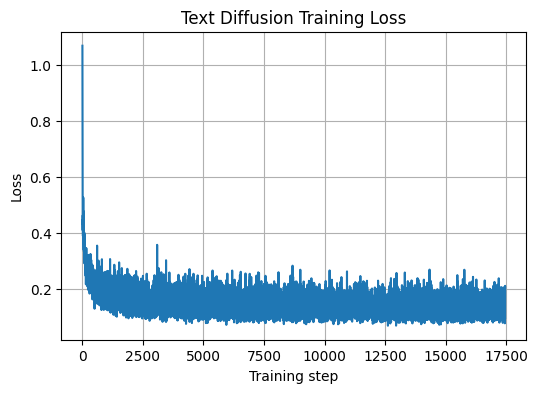

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("Text Diffusion Training Loss")
plt.grid(True)
plt.show()

### What is actually being optimized?

The loss optimized here is a **sum of three terms**:

1. **Diffusion loss (MSE)**  
   Encourages the model to predict clean embeddings from noisy ones.

2. **Token reconstruction loss (Cross-Entropy)**  
   Ensures embeddings remain decodable into real words.

3. **Endpoint regularization**  
   Stabilizes behavior at the start and end of the diffusion chain.

This combination is what allows diffusion to work for text,
despite text being fundamentally discrete.

## Generating Text and Extracting Embeddings with a Diffusion Model

In this section, we will generate text from a trained text diffusion model.
Conceptually, this mirrors image diffusion — except we diffuse and denoise token embeddings instead of pixels.

### High-level intuition
Key idea

1.	Text is first represented as continuous embeddings

2.	The diffusion process:

	•	adds noise in embedding space (forward process)

	•	learns to remove noise (reverse process)

3.	Only at the very end do we convert embeddings → discrete tokens

This is why text diffusion is fundamentally harder than image diffusion:

> **language is discrete, but diffusion is continuous**

### Switch the model to evaluation mode

Before sampling, disable training-specific behavior.

In [25]:
wrapped_model.eval()
torch.set_grad_enabled(False)

torch.autograd.grad_mode.set_grad_enabled(mode=False)

### What exactly does the model generate?

During sampling, the diffusion model produces a tensor:

In [26]:
[batch_size, seq_len, embed_dim]

[16, 32, 64]

This represents denoised token embeddings, not tokens themselves.

We must decode them using the model’s LM head.


### Helper: decode embeddings → text

<font color="orange">Note:
We use greedy decoding for clarity. Sampling strategies (top-k, nucleus) can be added later.</font>

In [27]:
def decode_embeddings(x, model, tokenizer):
    """
    Convert continuous embeddings into text via the LM head.

    x: Tensor of shape [B, L, D]
    """
    logits = model.get_logits(x)          # [B, L, vocab_size]
    token_ids = logits.argmax(dim=-1)     # greedy decoding

    texts = []
    for ids in token_ids:
        text = tokenizer.decode(
            ids.tolist(),
            skip_special_tokens=True
        )
        texts.append(text)
    return texts

### Sampling from pure noise (core diffusion loop)

This is the reverse diffusion process.

In [28]:
import torch.nn.functional as F

def decode_by_nearest_embedding(x, model, tokenizer, topk=1):
    """
    x: [B, L, D] continuous embeddings
    Returns decoded strings by nearest neighbor in embedding table.
    """
    net = model.module  # underlying TransformerNetModel
    # Token embedding matrix: [V, D]
    E = net.word_embedding.weight  # on DEVICE
    E = F.normalize(E, dim=-1)
    x = F.normalize(x, dim=-1)

    # cosine sim: [B, L, V]
    sims = torch.matmul(x, E.t())

    # either argmax or sample among top-k
    if topk == 1:
        token_ids = sims.argmax(dim=-1)
    else:
        top = torch.topk(sims, k=topk, dim=-1).indices  # [B, L, K]
        # sample uniformly from top-k (simple)
        pick = torch.randint(0, topk, top.shape[:-1], device=x.device)
        token_ids = top.gather(-1, pick.unsqueeze(-1)).squeeze(-1)

    texts = []
    for ids in token_ids:
        texts.append(tokenizer.decode(ids.tolist(), skip_special_tokens=True))
    return texts

In [29]:
batch_size = 4

sample_shape = (
    batch_size,
    cfg.sequence_len,
    cfg.in_channel,
)

samples = diffusion.p_sample_loop(
    model=wrapped_model,
    shape=sample_shape,
    device=DEVICE,
    progress=True,   # visualize denoising steps
)

  0%|          | 0/200 [00:00<?, ?it/s]

What happens internally:

```
Gaussian noise  →  x_T
x_T → x_{T-1} → ... → x_0  (learned denoising)
```

### Decode and inspect generated text

In [30]:
texts = decode_by_nearest_embedding(samples, wrapped_model, tokenizer, topk=5)
for i, t in enumerate(texts, 1):
    print(f"\n=== Sample {i} ===\n{t}")


=== Sample 1 ===
watermelon brussels steamed grapefruit arugula steamed celery watermelon . sticky stir garlic tangerine poached cantaloupe roasted crispy . clementine pumpkin brined kale lettuce yummy zucchini purple stewed pea brussels

=== Sample 2 ===
nectarine hard fresh is tangerine - fried strawberry blue cabbage fried black spicy tomato pea celery banana persimmon . white celery grapefruit zucchini hot salty tasty tamarind

=== Sample 3 ===
fish sunflower sunflower is tomato barbecued sprout eggplant raspberry nectarine sweet mushroom black papaya brown sunflower endive lemon soft red pecan coconut candied pink coconut rutabaga okra durian mushroom

=== Sample 4 ===
bitter orange brown brined stir cucumber pecan . watermelon black durian cashew papaya orange purple kale stewed radicchio pistachio microwaved . eggplant cold salty carrot sprout steamed honeydew deep


What to expect

- Early training: short, repetitive, semi-grammatical phrases

- More training: clearer structure, dataset-specific patterns

- This is normal for text diffusion models

### Optional: control noise with top_p

You can limit extreme Gaussian noise during denoising:

In [31]:
samples = diffusion.p_sample_loop(
    model=wrapped_model,
    shape=sample_shape,
    device=DEVICE,
    progress=True,
    top_p=0.9,   # lower = more conservative generation
)

  0%|          | 0/200 [00:00<?, ?it/s]

This often improves stability for small models.

In [32]:
texts = decode_by_nearest_embedding(samples, wrapped_model, tokenizer, topk=5)
for i, t in enumerate(texts, 1):
    print(f"\n=== Sample {i} ===\n{t}")


=== Sample 1 ===
burnt peach pea yummy fig kiwi spinach hazelnut . sticky nectarine ginger jackfruit bitter banana pecan . rutabaga brown orange beet poached banana . banana marinated - eggplant potato delicious

=== Sample 2 ===
okra pear orange pomelo papaya green - smoked microwaved watermelon crunchy sweet blue dandelion durian braised candied sauteed cantaloupe hard asparagus soybean pecan soggy the deep the . mushroom pumpkin

=== Sample 3 ===
cold pear orange orange fig kiwi cured hazelnut cantaloupe boiled raspberry tasty rutabaga cantaloupe green spicy papaya spicy crispy bitter crispy dried microwaved durian frozen blanched white coconut purple tamarind pea

=== Sample 4 ===
okra smoked apricot ripe avocado lime cucumber poached ripe marinated the orange steamed delicious . ripe tamarind lemon lime orange blue mushroom delicious banana red banana dried tamarind green smooth


### Baseline comparison: random embeddings

In [33]:
random_embeds = torch.randn(sample_shape, device=DEVICE)
random_texts = decode_embeddings(random_embeds, wrapped_model, tokenizer)

print("\n--- Random baseline (no diffusion) ---")
for t in random_texts:
    print(t)


--- Random baseline (no diffusion) ---
apricot blackberry greasy bitter pumpkin cantaloupe grapefruit mango yellow fig guava pepper sprout macadamia ginger sour blackberry dried boiled burnt artichoke red the persimmon tamarind onion squash cabbage sauteed pineapple salty squash
- kiwi persimmon red stewed microwaved cold cauliflower yam poached pink aged carrot banana brussels grape olive brussels blackberry hard cooked marinated coconut cucumber sunflower lychee macadamia hot broccoli
fig apple melon brown jackfruit hard zucchini broccoli hot hot pumpkin carrot . papaya greasy steamed burnt apricot rotten peanut bean okra fried kale roasted fresh yam apricot red brussels pepper
hard cooked collard spinach sauteed cooked sour fig apricot grilled asparagus soggy smooth pomelo raw pink barbecued stir olive fig cucumber cherry peach lychee fig zucchini coconut


### Key takeaways

• Diffusion models for text operate in **continuous embedding space**

• Discrete tokens only appear at the **final decoding step**

• Training teaches the model to denoise embeddings, not tokens

• This explains why text diffusion is harder than image diffusion

### Extract token embeddings and visualize with PCA/UMAP

In [34]:
def token_id_for_word(tokenizer, word: str):
    # HF-style tokenizers
    if hasattr(tokenizer, "encode"):
        ids = tokenizer.encode(word)
        # for single-word tokenizers, you often get special tokens too
        # keep only non-special if possible
        if hasattr(tokenizer, "all_special_ids"):
            ids = [i for i in ids if i not in set(tokenizer.all_special_ids)]
        return ids[0] if len(ids) > 0 else None
    return None

words = ["salty", "grapefruit", "cucumber", "fried", "squash", "bitter"]
word_to_id = {w: token_id_for_word(tokenizer, w) for w in words}
word_to_id

{'salty': 106,
 'grapefruit': 128,
 'cucumber': 48,
 'fried': 18,
 'squash': 50,
 'bitter': 56}

### Extract “static” token embeddings

In [35]:
import torch
import numpy as np

def get_embedding_matrix(model):
    # works because our wrapper exposes .module
    net = model.module
    emb = net.word_embedding.weight.detach().cpu().numpy()  # [vocab, dim]
    return emb

E = get_embedding_matrix(wrapped_model)
E.shape

(165, 64)

In [36]:
selected = [(w, i) for w, i in word_to_id.items() if i is not None]
selected

[('salty', 106),
 ('grapefruit', 128),
 ('cucumber', 48),
 ('fried', 18),
 ('squash', 50),
 ('bitter', 56)]

In [37]:
vecs = np.stack([E[i] for _, i in selected], axis=0)  # [n, dim]
labels = [w for w, _ in selected]
vecs.shape, labels

((6, 64), ['salty', 'grapefruit', 'cucumber', 'fried', 'squash', 'bitter'])

### 2D visualization with PCA

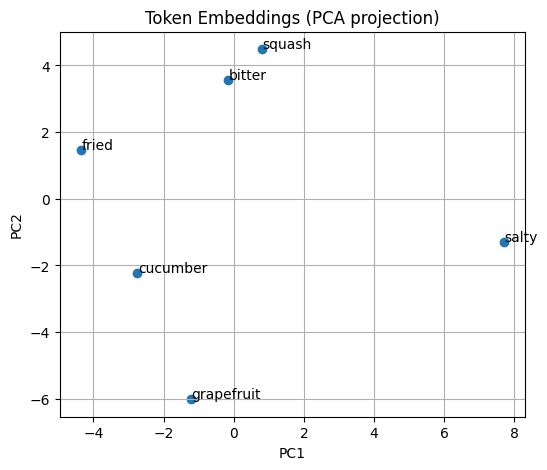

In [38]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
xy = pca.fit_transform(vecs)

plt.figure(figsize=(6, 5))
plt.scatter(xy[:, 0], xy[:, 1])

for (x, y), label in zip(xy, labels):
    plt.text(x + 0.02, y + 0.02, label)

plt.title("Token Embeddings (PCA projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

### Diffusion-specific embeddings: denoised contextual embeddings at different timesteps

This is the more diffusion-native view.

Idea:

- take a real sentence

- embed it → x₀

- add noise at timestep t → xₜ

- ask model to predict x₀ from xₜ

- extract the predicted embedding for certain positions/words

Encode one sentence and locate word positions

In [39]:
sentence = "i love fried cucumber"
ids = tokenizer.encode(sentence)
# strip special tokens if present
if hasattr(tokenizer, "all_special_ids"):
    ids = [i for i in ids if i not in set(tokenizer.all_special_ids)]

# pad/truncate
pad_id = getattr(tokenizer, "pad_token_id", 0)
ids = ids[:cfg.sequence_len] + [pad_id] * (cfg.sequence_len - len(ids))

input_ids = torch.tensor([ids], device=DEVICE)
attention_mask = (input_ids != pad_id).long()
input_ids.shape

torch.Size([1, 32])

Pick a timestep grid:

In [40]:
ts = [0, cfg.diffusion_steps//4, cfg.diffusion_steps//2, 3*cfg.diffusion_steps//4, cfg.diffusion_steps-1]
ts

[0, 50, 100, 150, 199]

Get predicted x0 embeddings at each timestep

In [41]:
def predict_x0_embeddings_at_t(model, diffusion, input_ids, attention_mask, t_scalar: int):
    model.eval()
    B, L = input_ids.shape
    t = torch.full((B,), t_scalar, device=input_ids.device, dtype=torch.long)

    # x_start_mean from embeddings
    x0_mean = model.module.get_embeds(input_ids)  # [B, L, D]

    # create x0 sample with std at t=0 used in repo
    std0 = torch.tensor(diffusion.sqrt_one_minus_alphas_cumprod[0], device=input_ids.device).float()
    x0 = x0_mean + std0 * torch.randn_like(x0_mean)

    # forward diffuse to x_t
    noise = torch.randn_like(x0)
    x_t = diffusion.q_sample(x0, t, noise=noise)

    # model predicts x_start (since predict_xstart=True in your args)
    x0_pred = model(x_t, diffusion._scale_timesteps(t), attention_mask=attention_mask)

    return x0_pred.detach().cpu().numpy(), x0_mean.detach().cpu().numpy()

preds = []
for t in ts:
    x0_pred, x0_mean = predict_x0_embeddings_at_t(wrapped_model, diffusion, input_ids, attention_mask, t)
    preds.append((t, x0_pred[0], x0_mean[0]))  # [L, D]

Visualize how embeddings “move” across timesteps

In [42]:
# Pick a few token positions (e.g., first 4 non-pad tokens):

nonpad = (input_ids[0].cpu().numpy() != pad_id).nonzero()[0].tolist()
positions = nonpad[:4]  # choose first few tokens
positions

[0, 1]

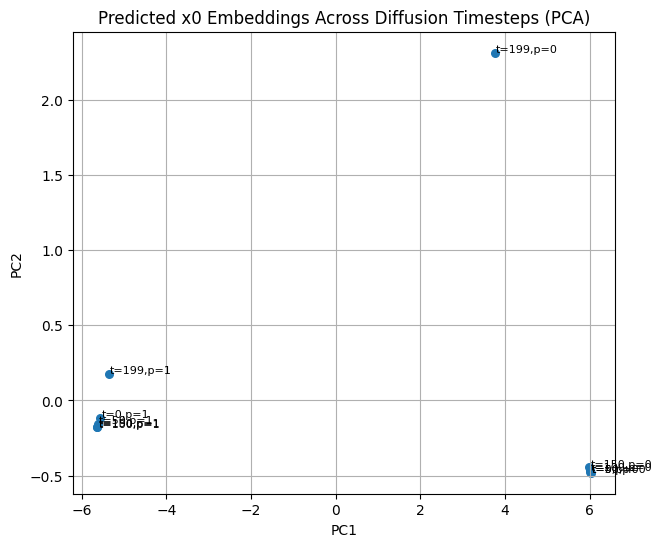

In [43]:
# Now project the predicted embeddings to 2D with PCA (fit on all timesteps + positions):
all_vecs = []
all_labels = []
for t, x0_pred_LD, _ in preds:
    for pos in positions:
        all_vecs.append(x0_pred_LD[pos])
        all_labels.append((t, pos))

all_vecs = np.stack(all_vecs, axis=0)

pca = PCA(n_components=2)
xy = pca.fit_transform(all_vecs)

plt.figure(figsize=(7, 6))
plt.scatter(xy[:, 0], xy[:, 1], s=30)

# annotate: (t, pos)
for (x, y), (t, pos) in zip(xy, all_labels):
    plt.text(x + 0.02, y, f"t={t},p={pos}", fontsize=8)

plt.title("Predicted x0 Embeddings Across Diffusion Timesteps (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

# Homework Exericise

**1)** Play with hyper-parameters in `DiffusionConfig` class and report how 1 or 2 of them impacts model learning.

In [44]:
# Experiment with DiffusionConfig class
# EXPERIMENT: Change noise_schedule from "sqrt" to "cosine"
# The noise schedule determines how noise is added during the forward diffusion process.
# - "sqrt": sqrt schedule - tends to work well for text diffusion
# - "cosine": cosine schedule - originally proposed for image diffusion, smoother noise addition
# - "linear": linear schedule - simple but may be suboptimal for text
# 
# Expected impact: Cosine schedule adds noise more gradually, which may lead to 
# different training dynamics and potentially smoother loss curves.

@dataclass
class DiffusionConfigExperiment:
    # ===== Data =====
    dataset: str = "simple"
    train_txt_path: str = "data/simple-train.txt"
    val_txt_path: str = "data/simple-test.txt"
    sequence_len: int = 32
    batch_size: int = 16

    # ===== Diffusion process =====
    diffusion_steps: int = 200
    noise_schedule: str = "cosine"   # CHANGED from "sqrt" to "cosine"
    predict_xstart: bool = True    # model predicts x_0 (clean embedding)

    # ===== Model =====
    config_name: str = "bert-base-uncased"
    in_channel: int = 64           # embedding dimension
    out_channel: int = 64
    num_channels: int = 64         # Transformer hidden channels
    num_heads: int = 2
    dropout: float = 0.1

    # ===== Embeddings =====
    init_pretrained: bool = False
    use_pretrained_embeddings: bool = False
    freeze_embeddings: bool = False

    # ===== Optimization =====
    lr: float = 1e-4
    weight_decay: float = 0.0
    lr_anneal_steps: int = 25000

    # ===== Logging / checkpoints =====
    checkpoint_path: str = "ckpts/simple-experiment"


cfg_exp = DiffusionConfigExperiment()
os.makedirs(cfg_exp.checkpoint_path, exist_ok=True)

print("=== EXPERIMENT: Noise Schedule Comparison ===")
print(f"Original model: noise_schedule='sqrt'")
print(f"Experiment model: noise_schedule='cosine'")
print()
cfg_exp


=== EXPERIMENT: Noise Schedule Comparison ===
Original model: noise_schedule='sqrt'
Experiment model: noise_schedule='cosine'



DiffusionConfigExperiment(dataset='simple', train_txt_path='data/simple-train.txt', val_txt_path='data/simple-test.txt', sequence_len=32, batch_size=16, diffusion_steps=200, noise_schedule='cosine', predict_xstart=True, config_name='bert-base-uncased', in_channel=64, out_channel=64, num_channels=64, num_heads=2, dropout=0.1, init_pretrained=False, use_pretrained_embeddings=False, freeze_embeddings=False, lr=0.0001, weight_decay=0.0, lr_anneal_steps=25000, checkpoint_path='ckpts/simple-experiment')

## Creating the Model and Diffusion Process

We now instantiate the **Transformer denoiser** and the **Gaussian diffusion process**.

Recall the separation of concerns:
- The **model** learns *how* to denoise embeddings.
- The **diffusion object** defines *what noise is added* and *what loss is optimized*.

Both are created together using a factory method from the repository.

### Import the factory method

In [45]:
# Core factory method
from src.train_infer.factory_methods import create_model_and_diffusion

# Utilities for argument handling
from src.utils.args_utils import model_and_diffusion_defaults

### Build an argument dictionary

In [46]:
# Start from the repo defaults - USING EXPERIMENT CONFIG (cfg_exp)
args_exp = model_and_diffusion_defaults()

# ---- Diffusion settings ----
args_exp["diffusion_steps"] = cfg_exp.diffusion_steps
args_exp["noise_schedule"] = cfg_exp.noise_schedule  # COSINE instead of SQRT
args_exp["predict_xstart"] = cfg_exp.predict_xstart

# ---- Model architecture ----
args_exp["in_channel"] = cfg_exp.in_channel
args_exp["out_channel"] = cfg_exp.out_channel
args_exp["num_channels"] = cfg_exp.num_channels
args_exp["num_heads"] = cfg_exp.num_heads
args_exp["dropout"] = cfg_exp.dropout
args_exp["config_name"] = cfg_exp.config_name

# ---- Embeddings ----
args_exp["init_pretrained"] = cfg_exp.init_pretrained
args_exp["use_pretrained_embeddings"] = cfg_exp.use_pretrained_embeddings
args_exp["freeze_embeddings"] = cfg_exp.freeze_embeddings

# ---- Text specifics ----
# Vocabulary size is determined by the tokenizer.
# For the "simple" dataset, this is read from disk.
from src.utils.custom_tokenizer import create_tokenizer
tokenizer_exp = create_tokenizer(
    return_pretokenized=cfg_exp.use_pretrained_embeddings,
    path="data/simple"
)
args_exp["vocab_size"] = tokenizer_exp.vocab_size

# ---- Misc (safe defaults) ----
args_exp["class_cond"] = False
args_exp["learn_sigma"] = False
args_exp["sigma_small"] = False
args_exp["use_kl"] = False
args_exp["rescale_timesteps"] = False
args_exp["rescale_learned_sigmas"] = False
args_exp["timestep_respacing"] = ""
args_exp["model_arch"] = "transformer"
args_exp["training_mode"] = "diffusion-lm"
args_exp["logits_mode"] = 1
args_exp["use_checkpoint"] = False

print(f"Experiment uses noise_schedule: {args_exp['noise_schedule']}")


Experiment uses noise_schedule: cosine


### Instantiate model and diffusion

Run this cell before you create the model/diffusion:

In [47]:
# Skip patching - it was already done in cell 19
# If you get a recursion error, restart the kernel and run from the beginning
print("Using AutoConfig patch from cell 19 (no action needed here).")

Using AutoConfig patch from cell 19 (no action needed here).


In [48]:
model_exp, diffusion_exp = create_model_and_diffusion(**args_exp)

model_exp = model_exp.to(DEVICE)
model_exp.eval()  # we will switch to train() later

print("=== EXPERIMENT MODEL (cosine schedule) ===")
print(model_exp)

training mode is  diffusion-lm
training mode is  diffusion-lm
=== EXPERIMENT MODEL (cosine schedule) ===
TransformerNetModel(
  (time_embed): Sequential(
    (0): Linear(in_features=64, out_features=256, bias=True)
    (1): SiLU()
    (2): Linear(in_features=256, out_features=768, bias=True)
  )
  (input_transformers): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )

### What did we just create?

**Model**
- A time-conditioned Transformer (BERT encoder)
- Input: noisy token embeddings + diffusion timestep
- Output: predicted clean embeddings (x₀)

**Diffusion**
- A Gaussian forward process over embeddings
- A training loss combining:
  - diffusion MSE
  - token-level reconstruction loss
  - regularization at extreme timesteps

Together, they define the learning problem:
> “Given a noisy embedding sequence at step *t*, predict the clean embedding.”


### Sanity check: shapes and forward pass

Before training, we do a minimal forward sanity check.

In [49]:
# Create a dummy batch for experiment model
batch_size = 2
seq_len = cfg_exp.sequence_len
embed_dim = cfg_exp.in_channel

# Fake token IDs
dummy_input_ids = torch.randint(
    low=0,
    high=tokenizer_exp.vocab_size,
    size=(batch_size, seq_len),
    device=DEVICE,
)

# Get clean embeddings
with torch.no_grad():
    x0 = model_exp.get_embeds(dummy_input_ids)

print("Clean embedding shape:", x0.shape)

Clean embedding shape: torch.Size([2, 32, 64])


Now simulate one diffusion step:

In [50]:
# Sample random timesteps
t = torch.randint(
    low=0,
    high=cfg_exp.diffusion_steps,
    size=(batch_size,),
    device=DEVICE,
)

# Add noise using the diffusion process (experiment uses cosine schedule)
noise = torch.randn_like(x0)
x_t = diffusion_exp.q_sample(x0, t, noise=noise)

print("Noisy embedding shape:", x_t.shape)

Noisy embedding shape: torch.Size([2, 32, 64])


And run the denoiser:

In [51]:
with torch.no_grad():
    x0_pred = model_exp(x_t, t)

print("Predicted x0 shape:", x0_pred.shape)

Predicted x0 shape: torch.Size([2, 32, 64])


You should see:

In [52]:
(batch_size, seq_len, embed_dim)

(2, 32, 64)

for all three tensors.

### Key takeaway

At this point, we have verified that:

- Text is represented as **continuous embeddings**
- Gaussian noise is added via the diffusion process
- A Transformer conditioned on time can predict clean embeddings
- All tensor shapes line up correctly

We are now ready to define the **training loop**, where the model learns
to denoise embeddings across many timesteps.

## Training the Text Diffusion Model

### What happens during training

Training a diffusion model follows a simple repeated procedure:

For each batch:
1. Encode text into token embeddings (x₀)
2. Sample a diffusion timestep t
3. Add Gaussian noise → xₜ
4. Ask the Transformer to predict x₀ from (xₜ, t)
5. Compute diffusion + token reconstruction loss
6. Update model parameters

All diffusion math is handled by the `diffusion` object.
We only need to call it correctly.

### Build the dataloader

We reuse the repo's sentencepiece utilities to stay faithful.

In [53]:
from src.utils import data_utils_sentencepiece

train_dataloader_exp = data_utils_sentencepiece.get_dataloader(
    tokenizer=tokenizer_exp,
    data_path=cfg_exp.train_txt_path,
    batch_size=cfg_exp.batch_size,
    max_seq_len=cfg_exp.sequence_len,
)

val_dataloader_exp = data_utils_sentencepiece.get_dataloader(
    tokenizer=tokenizer_exp,
    data_path=cfg_exp.val_txt_path,
    batch_size=cfg_exp.batch_size,
    max_seq_len=cfg_exp.sequence_len,
)

### Optimizer setup

In [54]:
import torch.nn as nn

class _ModelHolderExp:
    """Simple holder so code can do model.model.module like in DDP wrappers."""
    def __init__(self, module: nn.Module):
        self.module = module

class DiffusionCompatWrapperExp(nn.Module):
    """
    Compatibility wrapper for this repo's diffusion code.
    Supports BOTH:
      - model.module.* (DDP style)
      - model.model.module.* (their internal wrapper style)
    """
    def __init__(self, net: nn.Module):
        super().__init__()
        self.net = net
        self.model = _ModelHolderExp(net)  # so .model.module exists

    @property
    def module(self):
        # so .module exists
        return self.net

    def forward(self, *args, **kwargs):
        return self.net(*args, **kwargs)

    # Convenience passthroughs (sometimes used in sampling/logging)
    def get_embeds(self, *args, **kwargs):
        return self.net.get_embeds(*args, **kwargs)

    def get_logits(self, *args, **kwargs):
        return self.net.get_logits(*args, **kwargs)

# Re-wrap the experiment model (cosine schedule)
wrapped_model_exp = DiffusionCompatWrapperExp(model_exp).to(DEVICE)
wrapped_model_exp.train()

print("EXPERIMENT Compat wrapper ready:",
      "has .module ->", hasattr(wrapped_model_exp, "module"),
      "has .model.module ->", hasattr(wrapped_model_exp, "model") and hasattr(wrapped_model_exp.model, "module"))

EXPERIMENT Compat wrapper ready: has .module -> True has .model.module -> True


In [55]:
model_exp.train()

optimizer_exp = torch.optim.AdamW(wrapped_model_exp.parameters(), lr=cfg_exp.lr, weight_decay=cfg_exp.weight_decay)

In [56]:
def unpack_batch(batch, device):
    """
    Supports:
      - dict: {"input_ids": ..., "attention_mask": ...}
      - tuple: (None, {...})  <-- what this repo returns
      - tuple: (input_ids, attention_mask)
      - tuple: (input_ids,)
    """
    if batch is None:
        raise ValueError("Got batch=None. Something is wrong with the DataLoader.")

    # Case 1: already a dict
    if isinstance(batch, dict):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch.get("attention_mask", None)
        if attention_mask is not None:
            attention_mask = attention_mask.to(device)
        return input_ids, attention_mask

    # Case 2: tuple/list
    if isinstance(batch, (tuple, list)):
        # Special case: (None, dict)
        if len(batch) == 2 and batch[0] is None and isinstance(batch[1], dict):
            return unpack_batch(batch[1], device)

        # Common cases: (input_ids,) or (input_ids, attention_mask)
        if len(batch) >= 1 and hasattr(batch[0], "to"):
            input_ids = batch[0].to(device)
            attention_mask = batch[1].to(device) if len(batch) > 1 and hasattr(batch[1], "to") else None
            return input_ids, attention_mask

        raise ValueError(f"Unrecognized tuple batch structure: {batch}")

    raise TypeError(f"Unexpected batch type: {type(batch)}")

In [57]:
# If this prints a number, your training loop will run.
b = next(iter(train_dataloader_exp))
input_ids, attention_mask = unpack_batch(b, DEVICE)
t = torch.randint(0, cfg_exp.diffusion_steps, (input_ids.size(0),), device=DEVICE)

out = diffusion_exp.training_losses(
    model=wrapped_model_exp,
    x_start_never_used=None,
    t=t,
    model_kwargs={"input_ids": input_ids, "attention_mask": attention_mask},
)
print("Experiment model test:", out.keys(), out["loss"].mean().item())

Experiment model test: dict_keys(['mse', 'loss']) 1.234004259109497


### One training step

This cell is the conceptual heart of the notebook. We are using Mixed precision (AMP) to speed up the process.

In [58]:
from torch.cuda.amp import autocast, GradScaler

scaler_exp = GradScaler(enabled=(DEVICE=="cuda"))

def diffusion_train_step_amp_exp(model, diffusion, batch, optimizer, cfg):
    optimizer.zero_grad(set_to_none=True)
    input_ids, attention_mask = unpack_batch(batch, DEVICE)
    batch_size = input_ids.size(0)

    t = torch.randint(0, cfg.diffusion_steps, (batch_size,), device=DEVICE)

    model_kwargs = {"input_ids": input_ids}
    if attention_mask is not None:
        model_kwargs["attention_mask"] = attention_mask

    with autocast(enabled=(DEVICE=="cuda")):
        losses = diffusion.training_losses(
            model=model,
            x_start_never_used=None,
            t=t,
            model_kwargs=model_kwargs,
        )
        loss = losses["loss"].mean()

    scaler_exp.scale(loss).backward()
    scaler_exp.step(optimizer)
    scaler_exp.update()
    return float(loss.detach().cpu())

/tmp/ipython-input-806985284.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_exp = GradScaler(enabled=(DEVICE=="cuda"))


### Training loop

We intentionally keep this short and explicit.

☕ Coffee break time! This training run is time-consuming. You can interrupt it after about 30 minutes and proceed to the next section.

In [ ]:
from tqdm.auto import tqdm
from torch.cuda.amp import autocast, GradScaler


# Speed optimizations
if torch.cuda.is_available():
    # Matmul precision: "high" often enables TF32 where appropriate
    torch.set_float32_matmul_precision("high")

    # New backend knobs (replacing allow_tf32 flags)
    try:
        torch.backends.cuda.matmul.fp32_precision = "tf32"   # or "ieee"
    except Exception:
        pass
    try:
        torch.backends.cudnn.conv.fp32_precision = "tf32"    # or "ieee"
    except Exception:
        pass

from torch.amp import autocast, GradScaler

amp_device = "cuda" if torch.cuda.is_available() else "cpu"
scaler_exp = GradScaler(amp_device, enabled=(amp_device == "cuda"))


# =====================================
# EXPERIMENT Training loop (cosine noise schedule)
# =====================================
print("=== Training EXPERIMENT model (cosine noise schedule) ===")
print(f"Original model used: noise_schedule='sqrt'")
print(f"Experiment model uses: noise_schedule='cosine'")
print()

num_epochs = 1
# NOTE: get_dataloader returns an INFINITE generator, so we must set an explicit step limit
# Use same steps as original training, or fallback to 500 if original didn't run
steps_per_epoch = len(loss_history) if loss_history else 500
exp_loss_history = []  # DIFFERENT variable to compare with original loss_history

print(f"Training for {steps_per_epoch} steps per epoch")

# Re-enable gradient computation (was disabled in cell 53 for inference)
torch.set_grad_enabled(True)

wrapped_model_exp.train()

for epoch in range(num_epochs):
    pbar = tqdm(range(steps_per_epoch), desc=f"Experiment Epoch {epoch + 1}")
    for step in pbar:
        batch = next(train_dataloader_exp)
        optimizer_exp.zero_grad(set_to_none=True)

        input_ids, attention_mask = unpack_batch(batch, DEVICE)
        batch_size = input_ids.size(0)

        t = torch.randint(0, cfg_exp.diffusion_steps, (batch_size,), device=DEVICE)

        model_kwargs = {"input_ids": input_ids}
        if attention_mask is not None:
            model_kwargs["attention_mask"] = attention_mask

        with autocast(device_type=amp_device, enabled=(amp_device == "cuda")):
            losses = diffusion_exp.training_losses(
                model=wrapped_model_exp,
                x_start_never_used=None,
                t=t,
                model_kwargs=model_kwargs,
            )
            loss = losses["loss"].mean()

        scaler_exp.scale(loss).backward()
        scaler_exp.step(optimizer_exp)
        scaler_exp.update()

        exp_loss_history.append(loss.item())
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})

print(f"\nExperiment training complete! {len(exp_loss_history)} steps recorded.")

=== Training EXPERIMENT model (cosine noise schedule) ===
Original model used: noise_schedule='sqrt'
Experiment model uses: noise_schedule='cosine'



Experiment Epoch 1: 0it [00:00, ?it/s]

: 

### Plot training loss

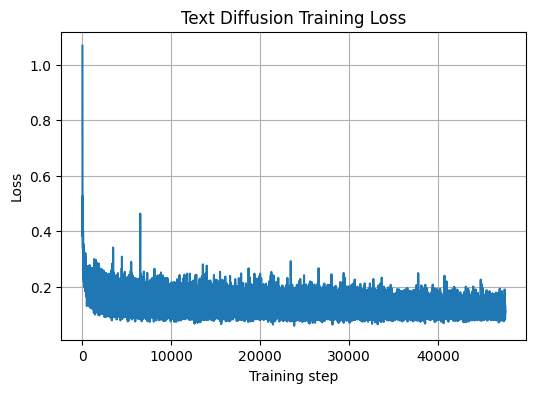

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# =====================================
# SIDE-BY-SIDE COMPARISON: Training Loss
# =====================================
# Compare original model (sqrt schedule) vs experiment model (cosine schedule)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Both curves overlaid
ax1 = axes[0]
# Ensure we have the same number of steps for fair comparison
min_steps = min(len(loss_history), len(exp_loss_history))
ax1.plot(loss_history[:min_steps], label='Original (sqrt schedule)', alpha=0.8, color='#2563eb')
ax1.plot(exp_loss_history[:min_steps], label='Experiment (cosine schedule)', alpha=0.8, color='#dc2626')
ax1.set_xlabel("Training step")
ax1.set_ylabel("Loss")
ax1.set_title("Training Loss Comparison: sqrt vs cosine noise schedule")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right plot: Smoothed curves for clearer comparison
ax2 = axes[1]
def smooth(y, window=50):
    """Simple moving average smoothing."""
    if len(y) < window:
        return y
    return np.convolve(y, np.ones(window)/window, mode='valid')

smooth_original = smooth(loss_history[:min_steps])
smooth_experiment = smooth(exp_loss_history[:min_steps])

ax2.plot(smooth_original, label='Original (sqrt) - smoothed', linewidth=2, color='#2563eb')
ax2.plot(smooth_experiment, label='Experiment (cosine) - smoothed', linewidth=2, color='#dc2626')
ax2.set_xlabel("Training step")
ax2.set_ylabel("Loss (smoothed)")
ax2.set_title("Smoothed Training Loss (window=50)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n=== Training Loss Summary ===")
print(f"{'Metric':<25} {'Original (sqrt)':<20} {'Experiment (cosine)':<20}")
print("-" * 65)
print(f"{'Initial loss (step 1)':<25} {loss_history[0]:<20.4f} {exp_loss_history[0]:<20.4f}")
print(f"{'Final loss':<25} {loss_history[-1]:<20.4f} {exp_loss_history[-1]:<20.4f}")
print(f"{'Mean loss':<25} {np.mean(loss_history):<20.4f} {np.mean(exp_loss_history):<20.4f}")
print(f"{'Min loss':<25} {np.min(loss_history):<20.4f} {np.min(exp_loss_history):<20.4f}")
print(f"{'Loss reduction':<25} {(loss_history[0]-loss_history[-1]):<20.4f} {(exp_loss_history[0]-exp_loss_history[-1]):<20.4f}")

# =====================================
# A) COMPARING GENERATED TEXT: Original vs Experiment
# =====================================
# Generate samples from both models and compare text quality

import torch.nn.functional as F

def decode_by_nearest_embedding_compare(x, model, tokenizer, topk=5):
    """
    x: [B, L, D] continuous embeddings
    Returns decoded strings by nearest neighbor in embedding table.
    """
    net = model.module  # underlying TransformerNetModel
    E = net.word_embedding.weight  # on DEVICE
    E = F.normalize(E, dim=-1)
    x = F.normalize(x, dim=-1)
    sims = torch.matmul(x, E.t())
    
    if topk == 1:
        token_ids = sims.argmax(dim=-1)
    else:
        top = torch.topk(sims, k=topk, dim=-1).indices
        pick = torch.randint(0, topk, top.shape[:-1], device=x.device)
        token_ids = top.gather(-1, pick.unsqueeze(-1)).squeeze(-1)
    
    texts = []
    for ids in token_ids:
        texts.append(tokenizer.decode(ids.tolist(), skip_special_tokens=True))
    return texts

# Switch both models to eval mode
wrapped_model.eval()
wrapped_model_exp.eval()
torch.set_grad_enabled(False)

batch_size = 4
sample_shape = (batch_size, cfg.sequence_len, cfg.in_channel)

print("=== Generating samples from ORIGINAL model (sqrt schedule) ===")
samples_original = diffusion.p_sample_loop(
    model=wrapped_model,
    shape=sample_shape,
    device=DEVICE,
    progress=True,
    top_p=0.9,
)
texts_original = decode_by_nearest_embedding_compare(samples_original, wrapped_model, tokenizer, topk=5)

print("\n=== Generating samples from EXPERIMENT model (cosine schedule) ===")
samples_exp = diffusion_exp.p_sample_loop(
    model=wrapped_model_exp,
    shape=sample_shape,
    device=DEVICE,
    progress=True,
    top_p=0.9,
)
texts_exp = decode_by_nearest_embedding_compare(samples_exp, wrapped_model_exp, tokenizer_exp, topk=5)

# Display side-by-side comparison
print("\n" + "="*80)
print("SIDE-BY-SIDE TEXT GENERATION COMPARISON")
print("="*80)
print(f"{'Original (sqrt schedule)':<40} | {'Experiment (cosine schedule)':<40}")
print("-"*80)

for i in range(batch_size):
    orig_text = texts_original[i][:38] + "..." if len(texts_original[i]) > 38 else texts_original[i]
    exp_text = texts_exp[i][:38] + "..." if len(texts_exp[i]) > 38 else texts_exp[i]
    print(f"{orig_text:<40} | {exp_text:<40}")

print("\n" + "="*80)
print("FULL GENERATED SAMPLES")
print("="*80)

print("\n--- ORIGINAL MODEL (sqrt schedule) ---")
for i, t in enumerate(texts_original, 1):
    print(f"Sample {i}: {t}")

print("\n--- EXPERIMENT MODEL (cosine schedule) ---")
for i, t in enumerate(texts_exp, 1):
    print(f"Sample {i}: {t}")

In [ ]:
# =====================================
# B) SIDE-BY-SIDE PCA: Word Embeddings Across Timesteps
# =====================================
# Compare how a specific word's embedding changes across diffusion timesteps
# in the original model vs experiment model

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Use the same sentence and word positions for both models
sentence = "i love fried cucumber"
ids = tokenizer.encode(sentence)
if hasattr(tokenizer, "all_special_ids"):
    ids = [i for i in ids if i not in set(tokenizer.all_special_ids)]

pad_id = getattr(tokenizer, "pad_token_id", 0)
ids = ids[:cfg.sequence_len] + [pad_id] * (cfg.sequence_len - len(ids))

input_ids = torch.tensor([ids], device=DEVICE)
attention_mask = (input_ids != pad_id).long()

# Pick a grid of timesteps
ts = [0, cfg.diffusion_steps//4, cfg.diffusion_steps//2, 3*cfg.diffusion_steps//4, cfg.diffusion_steps-1]

def predict_x0_embeddings_at_t_compare(model, diffusion, input_ids, attention_mask, t_scalar: int):
    """Get predicted x0 embeddings at a specific timestep."""
    model.eval()
    B, L = input_ids.shape
    t = torch.full((B,), t_scalar, device=input_ids.device, dtype=torch.long)
    
    x0_mean = model.module.get_embeds(input_ids)
    std0 = torch.tensor(diffusion.sqrt_one_minus_alphas_cumprod[0], device=input_ids.device).float()
    x0 = x0_mean + std0 * torch.randn_like(x0_mean)
    
    noise = torch.randn_like(x0)
    x_t = diffusion.q_sample(x0, t, noise=noise)
    
    x0_pred = model(x_t, diffusion._scale_timesteps(t), attention_mask=attention_mask)
    return x0_pred.detach().cpu().numpy(), x0_mean.detach().cpu().numpy()

# Get predictions from ORIGINAL model
preds_original = []
for t in ts:
    x0_pred, x0_mean = predict_x0_embeddings_at_t_compare(wrapped_model, diffusion, input_ids, attention_mask, t)
    preds_original.append((t, x0_pred[0], x0_mean[0]))

# Get predictions from EXPERIMENT model
preds_exp = []
for t in ts:
    x0_pred, x0_mean = predict_x0_embeddings_at_t_compare(wrapped_model_exp, diffusion_exp, input_ids, attention_mask, t)
    preds_exp.append((t, x0_pred[0], x0_mean[0]))

# Get non-pad positions (first 4 tokens: "i", "love", "fried", "cucumber")
nonpad = (input_ids[0].cpu().numpy() != pad_id).nonzero()[0].tolist()
positions = nonpad[:4]
word_labels = ["i", "love", "fried", "cucumber"][:len(positions)]

# Collect all vectors for joint PCA
all_vecs_original = []
all_labels_original = []
for t, x0_pred_LD, _ in preds_original:
    for pos in positions:
        all_vecs_original.append(x0_pred_LD[pos])
        all_labels_original.append((t, pos))

all_vecs_exp = []
all_labels_exp = []
for t, x0_pred_LD, _ in preds_exp:
    for pos in positions:
        all_vecs_exp.append(x0_pred_LD[pos])
        all_labels_exp.append((t, pos))

all_vecs_original = np.stack(all_vecs_original, axis=0)
all_vecs_exp = np.stack(all_vecs_exp, axis=0)

# Fit PCA jointly for comparable visualization
all_vecs_combined = np.vstack([all_vecs_original, all_vecs_exp])
pca = PCA(n_components=2)
pca.fit(all_vecs_combined)

xy_original = pca.transform(all_vecs_original)
xy_exp = pca.transform(all_vecs_exp)

# Create side-by-side PCA plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Colors for different words
colors = ['#e63946', '#2a9d8f', '#e9c46a', '#264653'][:len(positions)]
markers = ['o', 's', '^', 'D'][:len(positions)]

# Left plot: Original model (sqrt schedule)
ax1 = axes[0]
for i, (pos, word, color, marker) in enumerate(zip(positions, word_labels, colors, markers)):
    # Get indices for this position
    pos_indices = [j for j, (t, p) in enumerate(all_labels_original) if p == pos]
    x_coords = xy_original[pos_indices, 0]
    y_coords = xy_original[pos_indices, 1]
    
    # Plot trajectory
    ax1.plot(x_coords, y_coords, c=color, alpha=0.5, linewidth=1.5, linestyle='--')
    ax1.scatter(x_coords, y_coords, c=color, s=80, marker=marker, label=f'"{word}"', edgecolors='white', linewidth=1)
    
    # Annotate with timesteps
    for j, (x, y) in enumerate(zip(x_coords, y_coords)):
        t = ts[j]
        ax1.annotate(f't={t}', (x, y), fontsize=7, alpha=0.7, xytext=(3, 3), textcoords='offset points')

ax1.set_title("ORIGINAL Model (sqrt noise schedule)\nWord Embeddings Across Diffusion Timesteps", fontsize=11)
ax1.set_xlabel("PC1")
ax1.set_ylabel("PC2")
ax1.legend(loc='best', fontsize=9)
ax1.grid(True, alpha=0.3)

# Right plot: Experiment model (cosine schedule)
ax2 = axes[1]
for i, (pos, word, color, marker) in enumerate(zip(positions, word_labels, colors, markers)):
    pos_indices = [j for j, (t, p) in enumerate(all_labels_exp) if p == pos]
    x_coords = xy_exp[pos_indices, 0]
    y_coords = xy_exp[pos_indices, 1]
    
    ax2.plot(x_coords, y_coords, c=color, alpha=0.5, linewidth=1.5, linestyle='--')
    ax2.scatter(x_coords, y_coords, c=color, s=80, marker=marker, label=f'"{word}"', edgecolors='white', linewidth=1)
    
    for j, (x, y) in enumerate(zip(x_coords, y_coords)):
        t = ts[j]
        ax2.annotate(f't={t}', (x, y), fontsize=7, alpha=0.7, xytext=(3, 3), textcoords='offset points')

ax2.set_title("EXPERIMENT Model (cosine noise schedule)\nWord Embeddings Across Diffusion Timesteps", fontsize=11)
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.legend(loc='best', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle(f'Sentence: "{sentence}"', y=1.02, fontsize=12, fontweight='bold')
plt.show()

# Analysis: Compute trajectory distances
print("\n=== Embedding Trajectory Analysis ===")
print(f"Sentence: '{sentence}'")
print(f"Comparing how word embeddings change across timesteps {ts}")
print()

def compute_trajectory_length(xy, labels, pos):
    """Compute total trajectory length for a position."""
    pos_indices = [j for j, (t, p) in enumerate(labels) if p == pos]
    points = xy[pos_indices]
    total_dist = sum(np.linalg.norm(points[i+1] - points[i]) for i in range(len(points)-1))
    return total_dist

print(f"{'Word':<12} {'Original (sqrt)':<20} {'Experiment (cosine)':<20} {'Difference':<15}")
print("-" * 67)
for pos, word in zip(positions, word_labels):
    dist_orig = compute_trajectory_length(xy_original, all_labels_original, pos)
    dist_exp = compute_trajectory_length(xy_exp, all_labels_exp, pos)
    diff = dist_exp - dist_orig
    print(f"{word:<12} {dist_orig:<20.4f} {dist_exp:<20.4f} {diff:+15.4f}")

print("\nInterpretation: Larger trajectory = embedding changes more across timesteps")
print("The cosine schedule typically leads to different denoising dynamics.")

**2)** Propose one application of diffusion-based language models.

Diffusion models could enable iterative narrative synthesis. For my conspiracy research, this could model how communities collectively "workshop" narratives: starting from fragmented claims and gradually converging on coherent narratives through social deliberation. In practice, I would train a diffusion model on timestamped conspiracy forum posts, then condition the denoising process on early-stage fragments to generate intermediate narrative states. Each denoising step would represent a stage in the collective refinement process, allowing me to extract narrative elements at multiple timesteps and measure how semantic structures stabilize across iterations. This would essentially operationalize the otherwise opaque process of how conspiracy communities converge on shared imaginaries, particularly when generating novel conspiracy theories in times of crises (e.g., 9/11) by drawing on and recombining existing narratives (e.g., anti-Semitic themes). By analyzing intermediate denoising states, I could trace how narrative components crystallize from initial noise into stable conspiratorial narratives, revealing the deliberative process rather than just final outputs. This iterative refinement process is something sequential models struggle to capture authentically, and would approximate the collaborative aspect of conspiracy theorizing that recent sociological work has emphasized.

**3)** BONUS: What unique properties of language do diffusion-based embeddings encode that transformer-based embeddings fail to capture?

Diffusion-based embeddings capture **geometric trajectory information** and **multi-scale semantic structure** that transformer embeddings miss:

1. Continuous semantic paths: Diffusion embeddings encode the entire denoising trajectory from noise to text, revealing intermediate semantic states. Transformers only capture discrete token-to-token transitions, missing the continuous "journey" through semantic space.
2. Hierarchical abstraction levels: Different denoising timesteps naturally correspond to different levels of semantic granularity. Early steps capture high-level themes/topics whereas later steps refine specific details. Transformer embeddings conflate all semantic scales into fixed representations.
3. Uncertainty and ambiguity: Diffusion embeddings inherently represent distributional information about multiple plausible interpretations at each refinement stage. Transformer embeddings typically collapse to single point estimates, losing information about semantic uncertainty.

When comparing German vs. English conspiracy narratives, diffusion embeddings could reveal whether communities differ in their refinement trajectories. For example, do German forums crystallize narratives through different intermediate semantic states than English forums, even when final narratives appear similar? This captures cultural differences in narrative construction processes, not just outcomes.